# Etapa 2 — Perfil de Clientes
Análise do comportamento de compra no banco Northwind.

## 1. Receita Total por Cliente
Nesta etapa identificamos quais clientes mais geram receita.

In [3]:
from sqlalchemy import create_engine
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Conexão com o banco via SQLAlchemy
user = "user"
password = "password"
host = "localhost"
port = "1234"
database = "northwind"

engine = create_engine(f"postgresql+psycopg2://{user}:{password}@{host}:{port}/{database}")

In [4]:
def run_query(path):
    with open(path, "r",encoding="utf-8") as file:
        query = file.read()
    return pd.read_sql_query(query, engine)

# Caminho do arquivo .sql
df_receita = run_query("./sql/clientes_receita_total.sql")

# Exibe a tabela
df_receita.head()

,customer_id,company_name,receita_total
0,QUICK,QUICK-Stop,110277.305030
1,ERNSH,Ernst Handel,104874.978144
2,SAVEA,Save-a-lot Markets,104361.949540
3,RATTC,Rattlesnake Canyon Grocery,51097.800828
4,HUNGO,Hungry Owl All-Night Grocers,49979.905081


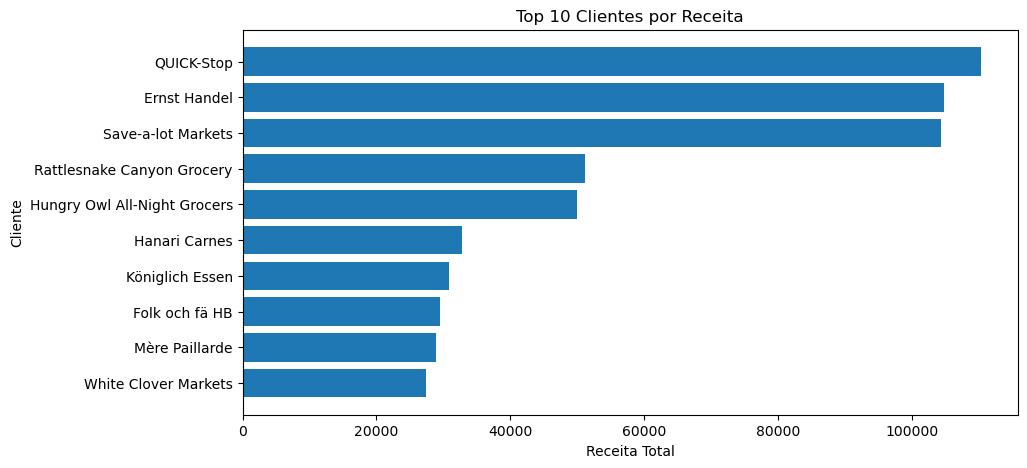

In [7]:
top10_receita = df_receita.sort_values("receita_total", ascending=False).head(10)
top10_receita

plt.figure(figsize=(10, 5))
plt.barh(top10_receita['company_name'], top10_receita['receita_total'])
plt.xlabel("Receita Total")
plt.ylabel("Cliente")
plt.title("Top 10 Clientes por Receita")
plt.gca().invert_yaxis()
plt.show()

## 2. Volume Total de Produtos por Cliente
Aqui avaliamos quem compra mais itens, independente do valor.

In [5]:
# Caminho do arquivo .sql
df_produtos = run_query("./sql/clientes_quant_total.sql")

# Exibe a tabela
df_produtos.head()

,customer_id,company_name,quantidade_total
0,SAVEA,Save-a-lot Markets,4958
1,ERNSH,Ernst Handel,4543
2,QUICK,QUICK-Stop,3961
3,HUNGO,Hungry Owl All-Night Grocers,1684
4,FRANK,Frankenversand,1525


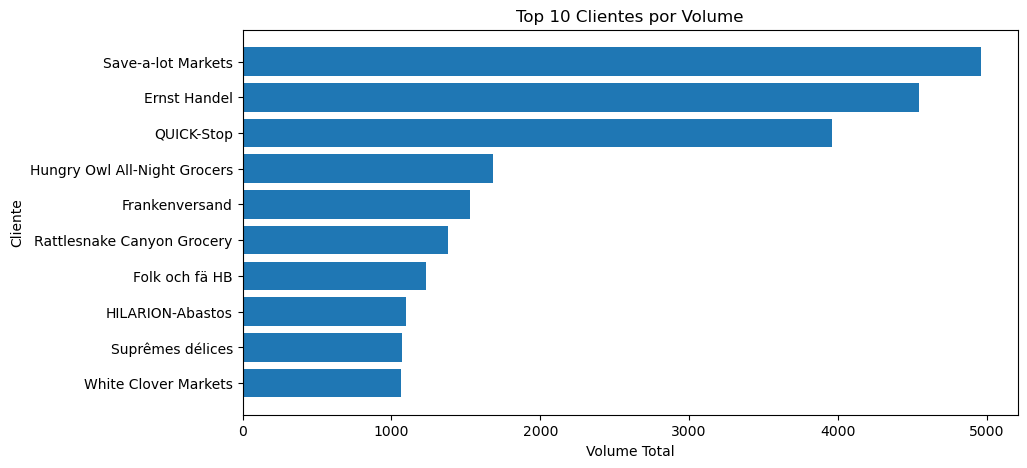

In [9]:
top10_produtos = df_produtos.sort_values("quantidade_total", ascending=False).head(10)
top10_produtos

plt.figure(figsize=(10, 5))
plt.barh(top10_produtos['company_name'], top10_produtos['quantidade_total'])
plt.xlabel("Volume Total")
plt.ylabel("Cliente")
plt.title("Top 10 Clientes por Volume")
plt.gca().invert_yaxis()
plt.show()

## 3. Ticket Médio por Cliente
Quanto cada cliente gasta em média por item.

In [10]:
# Caminho do arquivo .sql
df_ticket = run_query("./sql/ticket_medio_clientes.sql")

# Exibe a tabela
df_ticket.head()

,customer_id,company_name,total_pedidos,receita_total,ticket_medio
0,QUICK,QUICK-Stop,28,110277.305030,3938.475180
1,ERNSH,Ernst Handel,30,104874.978144,3495.832605
2,SAVEA,Save-a-lot Markets,31,104361.949540,3366.514501
3,RATTC,Rattlesnake Canyon Grocery,18,51097.800828,2838.766713
4,HUNGO,Hungry Owl All-Night Grocers,19,49979.905081,2630.521320


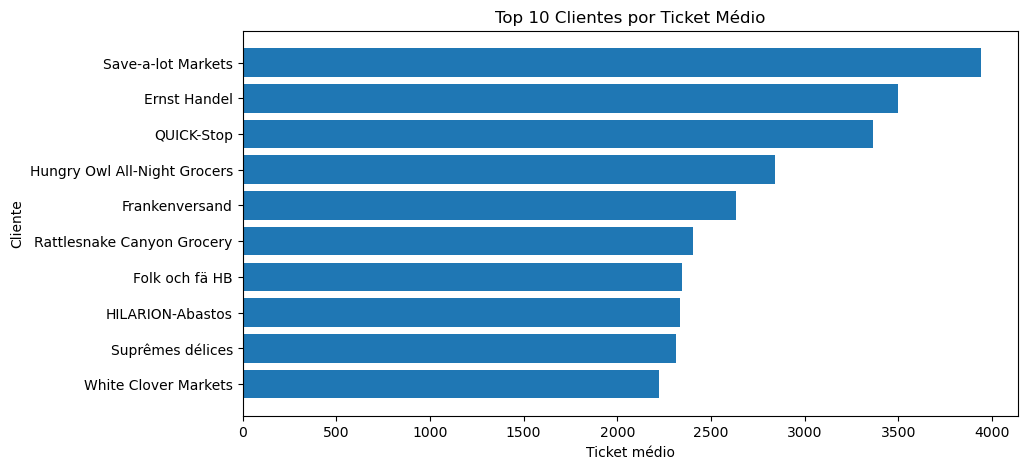

In [11]:
top10_ticket = df_ticket.sort_values("ticket_medio", ascending=False).head(10)
top10_ticket

plt.figure(figsize=(10, 5))
plt.barh(top10_produtos['company_name'], top10_ticket['ticket_medio'])
plt.xlabel("Ticket médio")
plt.ylabel("Cliente")
plt.title("Top 10 Clientes por Ticket Médio")
plt.gca().invert_yaxis()
plt.show()

## 4. Aplicação da Regra de Pareto
Verificamos se ~20% dos clientes geram ~80% da receita.

In [ ]:
with open('../queries/clientes_pareto.sql', 'r') as f:
    query_pareto = f.read()

df_pareto = pd.read_sql(query_pareto, engine)
df_pareto.head()

In [5]:
# Caminho do arquivo .sql
df_pareto = run_query("./sql/pareto.sql")

# Exibe a tabela
df_pareto.head()

,customer_id,company_name,receita_total
0,QUICK,QUICK-Stop,110277.305030
1,ERNSH,Ernst Handel,104874.978144
2,SAVEA,Save-a-lot Markets,104361.949540
3,RATTC,Rattlesnake Canyon Grocery,51097.800828
4,HUNGO,Hungry Owl All-Night Grocers,49979.905081


In [13]:
df_pareto_sorted = df_pareto.sort_values("receita_total", ascending=False)
df_pareto_sorted['receita_pct'] = df_pareto_sorted['receita_total'] / df_pareto_sorted['receita_total'].sum()
df_pareto_sorted['receita_acumulada'] = df_pareto_sorted['receita_pct'].cumsum()

# Total de clientes
total_clientes = len(df_pareto_sorted)

# Percentual acumulado de clientes
df_pareto_sorted['pct_clientes'] = (df_pareto_sorted.index + 1) / total_clientes

# Agora identifique o ponto onde a receita acumulada atinge 80%
limite_pareto = df_pareto_sorted[df_pareto_sorted['receita_acumulada'] >= 0.8].iloc[0]

clientes_pareto = limite_pareto['pct_clientes']

clientes_pareto


df_pareto_sorted.head()

,customer_id,company_name,receita_total,pct,acumulado,receita_pct,receita_acumulada,pct_clientes
0,QUICK,QUICK-Stop,110277.305030,0.087121,0.087121,0.087121,0.087121,0.011236
1,ERNSH,Ernst Handel,104874.978144,0.082853,0.169974,0.082853,0.169974,0.022472
2,SAVEA,Save-a-lot Markets,104361.949540,0.082448,0.252422,0.082448,0.252422,0.033708
3,RATTC,Rattlesnake Canyon Grocery,51097.800828,0.040368,0.292790,0.040368,0.292790,0.044944
4,HUNGO,Hungry Owl All-Night Grocers,49979.905081,0.039485,0.332275,0.039485,0.332275,0.056180


## 5. Visualizações
Gráficos criados a partir dos DataFrames acima.

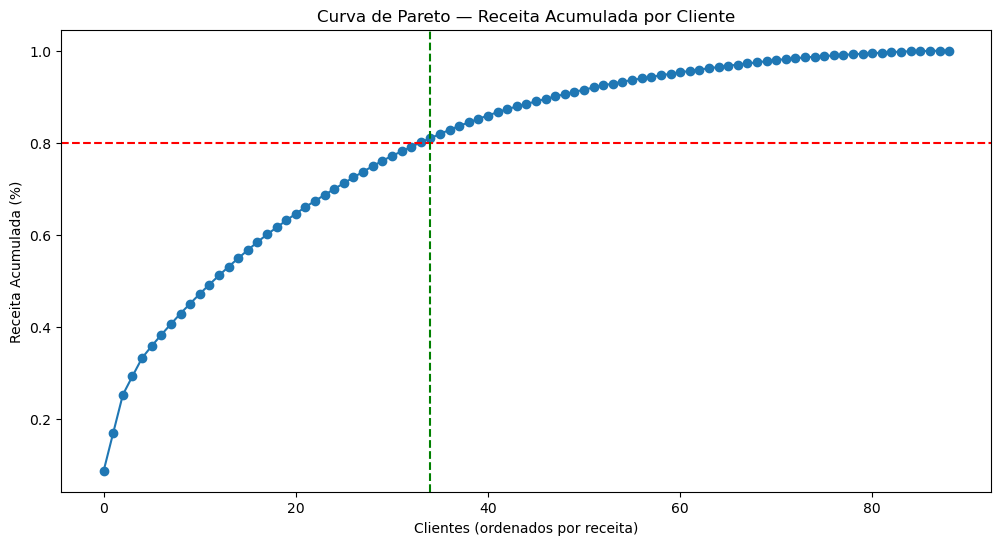

38.2% dos clientes geram 80% da receita.


In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

# Curva de receita acumulada
plt.plot(df_pareto_sorted['receita_acumulada'], marker='o')

# Linha de referência de 80%
plt.axhline(0.8, color='red', linestyle='--')

# Linha vertical indicando % de clientes responsáveis por 80%
plt.axvline(int(clientes_pareto * total_clientes), color='green', linestyle='--')

plt.title('Curva de Pareto — Receita Acumulada por Cliente')
plt.xlabel('Clientes (ordenados por receita)')
plt.ylabel('Receita Acumulada (%)')

plt.show()

# Encontrar o primeiro índice onde a receita acumulada alcança 80%
idx_80 = np.argmax(df_pareto_sorted['receita_acumulada'] >= 0.8)

# Quantidade de clientes até esse ponto
clientes_80 = idx_80 + 1  

# Total de clientes
total_clientes = len(df_pareto_sorted)

# Percentual de clientes
pct_clientes = (clientes_80 / total_clientes) * 100

print(f"{pct_clientes:.1f}% dos clientes geram 80% da receita.")


## 📌 Conclusão — Análise de Pareto (Etapa 2)

A análise do comportamento dos clientes demonstra um padrão claro de concentração de receita. Observamos que **38,2% dos clientes são responsáveis por 80% de toda a receita** da Northwind.  

Esse resultado indica que, embora a regra clássica de Pareto (80/20) nem sempre se aplique de forma exata, **o princípio da concentração permanece válido**: uma parcela relativamente pequena da base de clientes sustenta a maior parte do faturamento.

### 🔍 Principais insights

- A empresa **não depende apenas de um grupo extremamente pequeno** de clientes, o que reduz riscos de perda abrupta de receita caso um cliente importante pare de comprar.
- Ainda assim, existe uma **concentração significativa**, sugerindo que estratégias de **retenção, relacionamento e personalização** devem ser especialmente direcionadas aos clientes que compõem essa faixa de maior contribuição.
- Como ~40% dos clientes representam 80% da receita, pode haver oportunidade de:
  - **Aumentar o engajamento dos clientes de menor receita**, por meio de cross-sell e up-sell;
  - Criar **programas de fidelidade segmentados**, reforçando o relacionamento com os clientes de maior impacto no faturamento;
  - Avaliar se os clientes fora do grupo principal estão recebendo atenção comercial adequada, há espaço para fazê-los subir de faixa.

### 🧭 Conclusão geral da etapa
A análise de Pareto na base de clientes oferece clareza sobre **quem realmente impulsiona o faturamento** e orienta decisões estratégicas tanto para retenção quanto para crescimento. Essa etapa consolida um entendimento essencial para qualquer operação comercial: **não existe crescimento sustentável sem conhecer profundamente seus melhores clientes**.
